## Import Modules

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv("data.csv")
df

,index,Patient Id,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,0,P1,33,1,2,4,5,4,3,2,...,3,4,2,2,3,1,2,3,4,Low
1,1,P10,17,1,3,1,5,3,4,2,...,1,3,7,8,6,2,1,7,2,Medium
2,2,P100,35,1,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
3,3,P1000,37,1,7,7,7,7,6,7,...,4,2,3,1,4,5,6,7,5,High
4,4,P101,46,1,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,P995,44,1,6,7,7,7,7,6,...,5,3,2,7,8,2,4,5,3,High
996,996,P996,37,2,6,8,7,7,7,6,...,9,6,5,7,2,4,3,1,4,High
997,997,P997,25,2,4,5,6,5,5,4,...,8,7,9,2,1,4,6,7,2,High
998,998,P998,18,2,6,8,7,7,7,6,...,3,2,4,1,4,2,4,2,3,High


In [3]:
df.drop(df.columns[[0, 1]], axis=1, inplace=True)

In [4]:
df

,Age,Gender,Air Pollution,Alcohol use,Dust Allergy,OccuPational Hazards,Genetic Risk,chronic Lung Disease,Balanced Diet,Obesity,...,Fatigue,Weight Loss,Shortness of Breath,Wheezing,Swallowing Difficulty,Clubbing of Finger Nails,Frequent Cold,Dry Cough,Snoring,Level
0,33,1,2,4,5,4,3,2,2,4,...,3,4,2,2,3,1,2,3,4,Low
1,17,1,3,1,5,3,4,2,2,2,...,1,3,7,8,6,2,1,7,2,Medium
2,35,1,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
3,37,1,7,7,7,7,6,7,7,7,...,4,2,3,1,4,5,6,7,5,High
4,46,1,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,44,1,6,7,7,7,7,6,7,7,...,5,3,2,7,8,2,4,5,3,High
996,37,2,6,8,7,7,7,6,7,7,...,9,6,5,7,2,4,3,1,4,High
997,25,2,4,5,6,5,5,4,6,7,...,8,7,9,2,1,4,6,7,2,High
998,18,2,6,8,7,7,7,6,7,7,...,3,2,4,1,4,2,4,2,3,High


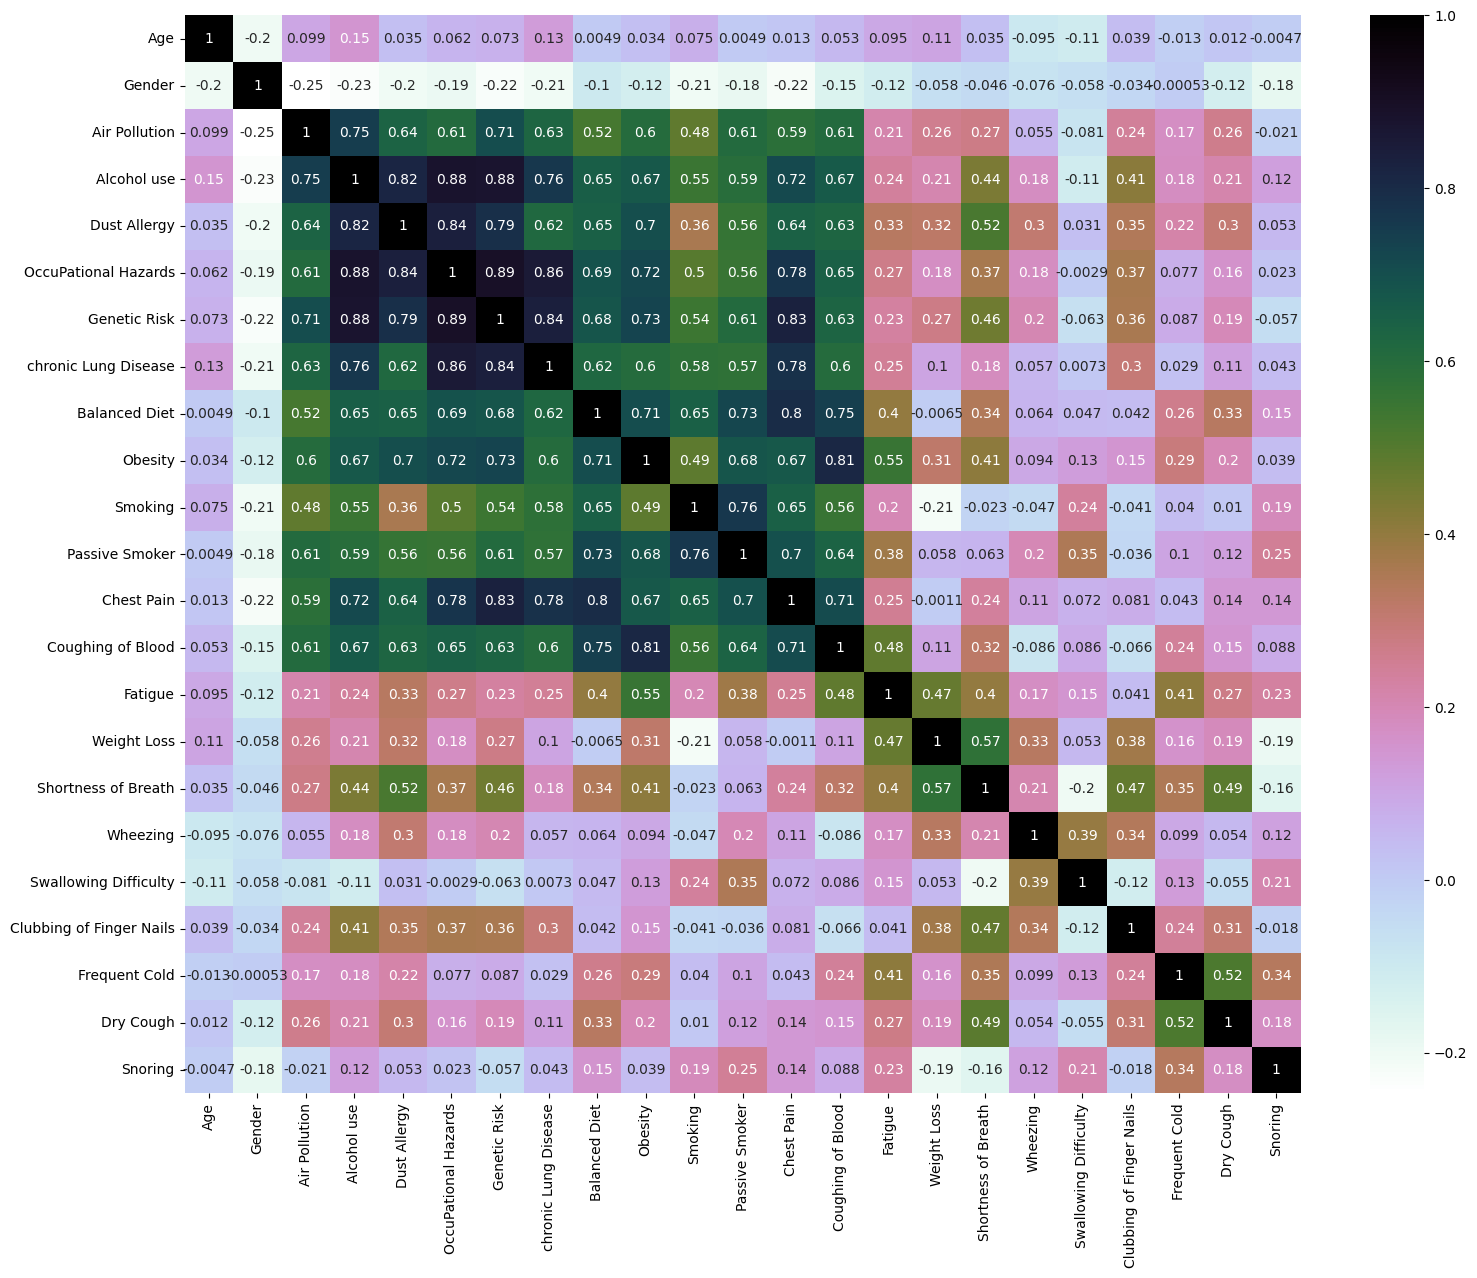

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns from the DataFrame
numeric_df = df.select_dtypes(include=['number'])  # This excludes non-numeric columns

# Create the heatmap with the numeric data
plt.figure(figsize=(18,14))
sns.heatmap(numeric_df.corr(), annot=True, cmap='cubehelix_r')  # Draws heatmap  
plt.show()


## Data Visualization 

In [7]:
df.columns

Index(['Age', 'Gender', 'Air Pollution', 'Alcohol use', 'Dust Allergy',
       'OccuPational Hazards', 'Genetic Risk', 'chronic Lung Disease',
       'Balanced Diet', 'Obesity', 'Smoking', 'Passive Smoker', 'Chest Pain',
       'Coughing of Blood', 'Fatigue', 'Weight Loss', 'Shortness of Breath',
       'Wheezing', 'Swallowing Difficulty', 'Clubbing of Finger Nails',
       'Frequent Cold', 'Dry Cough', 'Snoring', 'Level'],
      dtype='object')

In [8]:
mag="magma" 

<Axes: xlabel='Gender', ylabel='count'>

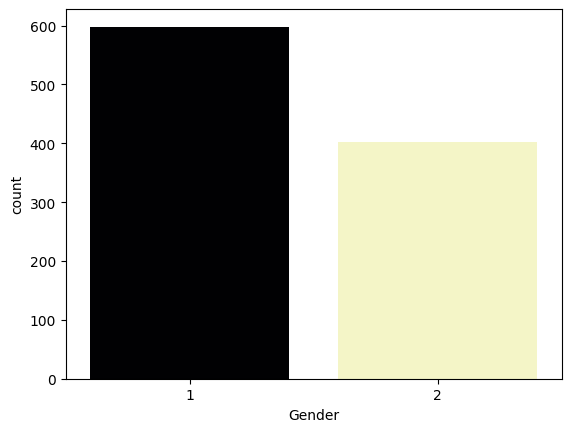

In [13]:
sns.countplot(x="Gender", data=df, hue="Gender", palette=mag, legend=False)


<Axes: xlabel='Level', ylabel='count'>

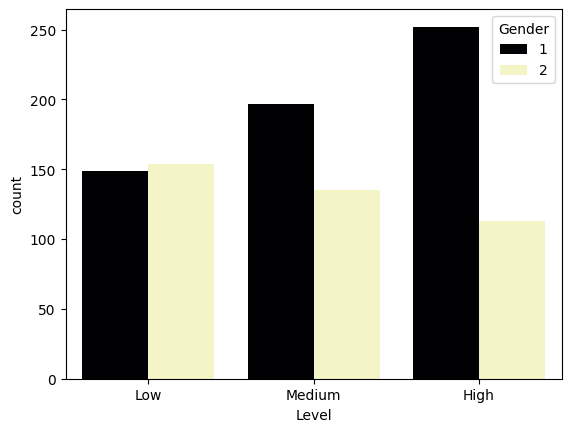

In [14]:
sns.countplot(x="Level",data=df,hue="Gender",palette=mag)

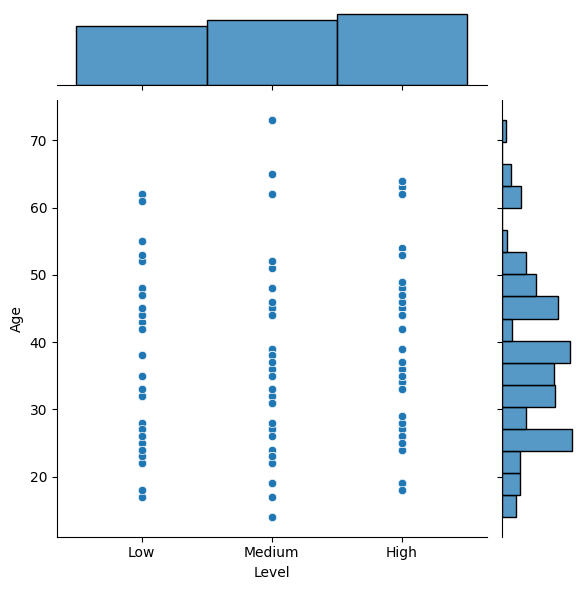

In [15]:
sns.jointplot(x="Level",y="Age",data=df,kind='scatter')

In [16]:
df["Obesity"].value_counts()

Obesity
7    356
3    193
4    191
2    140
1     70
6     30
5     20
Name: count, dtype: int64

<Axes: xlabel='Level', ylabel='count'>

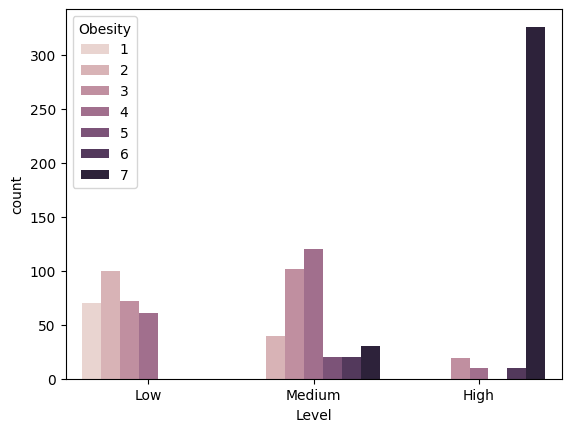

In [17]:
sns.countplot(x="Level",hue="Obesity",data=df)

In [18]:
sns.set(rc={'figure.figsize':(9,6.27)})

## Train Test Split

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [20]:
X = df.drop(columns='Level', axis =1)
Y = df['Level']

In [21]:
# training and test data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [22]:
print(X.shape, X_train.shape, X_test.shape)

(1000, 23) (800, 23) (200, 23)


## Dropping one of any Highly Co-related Values

In [23]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.80)
len(set(corr_features))


6

In [24]:
corr_features

{'Chest Pain',
 'Coughing of Blood',
 'Dust Allergy',
 'Genetic Risk',
 'OccuPational Hazards',
 'chronic Lung Disease'}

In [25]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [26]:
train_data=Y_test
train_data
train_data.to_csv("testy.csv")

In [28]:
print(type(train_data))


<class 'pandas.core.series.Series'>


## Checking co-relation again just to confirm

In [29]:

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.80)
len(set(corr_features))

0

## Logistic Regression model

In [30]:
model = LogisticRegression()

In [31]:
model.fit(X_train, Y_train)

C:\Users\user\.conda\envs\myenv\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
# accuracy score on the training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy*100)

Accuracy score of the training data :  98.375


In [33]:
# accuracy score on the test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy*100)

Accuracy score of the test data :  95.5


In [34]:

input_data = (62,1,6,8,7,7,8,7,3,2,4,1,4,2,4,2,3)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = model.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not Lung Cancer')
else:
  print('The Person has Lung Cancer Disease')

['High']
The Person has Lung Cancer Disease


C:\Users\user\.conda\envs\myenv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [35]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,X_test_prediction))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       0.89      0.97      0.93        61
      Medium       0.97      0.89      0.93        66

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



## Confusion Matrix explained

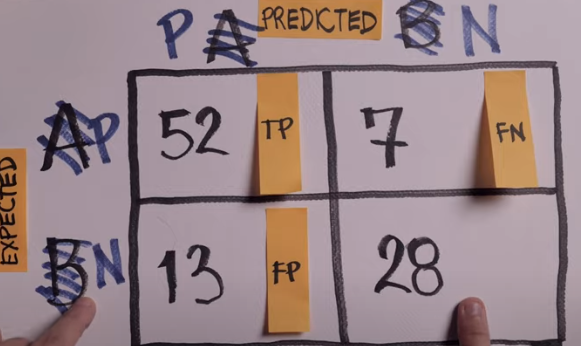

<Axes: >

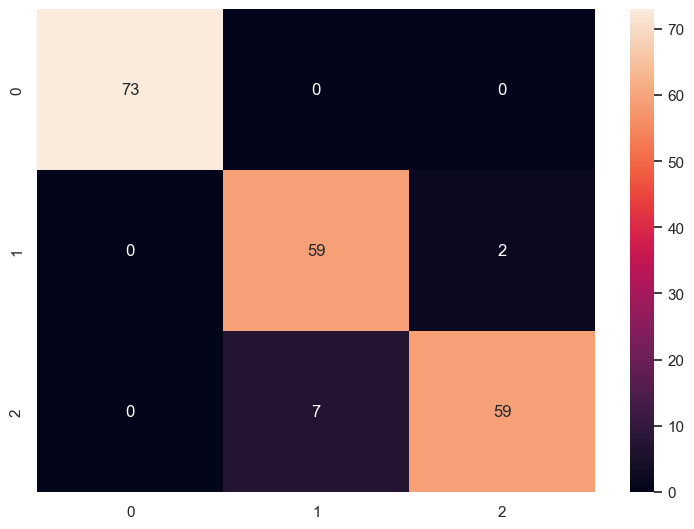

In [36]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(Y_test, X_test_prediction) 
sns.heatmap(cm, annot=True)

## For my Reference

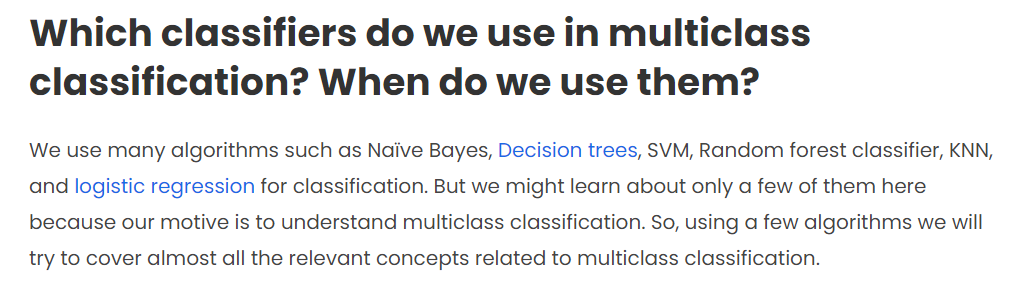

## Support Vector Machine SVM

In [37]:
from sklearn import svm
from sklearn import metrics # for checking the model accuracy

In [38]:
classifier = svm.SVC(kernel='linear')

# we train the algorithm with training data and training output
classifier.fit(X_train, Y_train)

# we pass the testing data to the stored algorithm to predict the outcome
prediction_svm = classifier.predict(X_test)
print('The accuracy of the SVM is: ', metrics.accuracy_score(prediction_svm, Y_test)) # we check the accuracy of the algorithm
#we pass the predicted output by the model and the actual output

The accuracy of the SVM is:  1.0


In [39]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction_svm))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 100% Accuracy is obtained from svm and logistic

## Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

In [41]:
dis_tree = DecisionTreeClassifier()
dis_tree.fit(X_train, Y_train)
prediction_dis = dis_tree.predict(X_test)
print('The accuracy of Decision Tree is: ', metrics.accuracy_score(prediction_dis, Y_test))

The accuracy of Decision Tree is:  1.0


In [42]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction_dis))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## KNN Model

In [43]:
from sklearn.neighbors import KNeighborsClassifier # KNN classifier

In [44]:
knn_m = KNeighborsClassifier(n_neighbors=3) # this examines 3 neighbors for putting the data into class
knn_m.fit(X_train, Y_train)
prediction1 = knn_m.predict(X_test)
print('The accuracy of KNN is: ', metrics.accuracy_score(prediction1, Y_test))

The accuracy of KNN is:  1.0


In [45]:
from sklearn.metrics import classification_report
print(classification_report(Y_test,prediction1))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00        73
         Low       1.00      1.00      1.00        61
      Medium       1.00      1.00      1.00        66

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [46]:
prediction1

array(['Medium', 'Low', 'Medium', 'High', 'Low', 'High', 'High', 'Medium',
       'High', 'High', 'High', 'Medium', 'Low', 'High', 'High', 'Medium',
       'Low', 'Medium', 'High', 'High', 'High', 'High', 'High', 'Medium',
       'Low', 'High', 'High', 'Low', 'Medium', 'Low', 'Low', 'Low', 'Low',
       'Low', 'Low', 'High', 'Medium', 'Low', 'Low', 'Low', 'Low', 'High',
       'High', 'Medium', 'Low', 'Low', 'High', 'Medium', 'High', 'Low',
       'High', 'Medium', 'Low', 'Medium', 'Low', 'Low', 'Medium', 'High',
       'Medium', 'High', 'Medium', 'Medium', 'Low', 'High', 'Low', 'High',
       'Medium', 'Medium', 'Medium', 'Low', 'Low', 'Medium', 'High',
       'Low', 'Low', 'Medium', 'Medium', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Low', 'High', 'Medium', 'Low',
       'Low', 'Low', 'Low', 'High', 'High', 'Low', 'Medium', 'Low',
       'Medium', 'High', 'Low', 'Medium', 'High', 'High', 'High', 'High',
       'Low', 'Medium', 'Medium', 'Medium', 'High', 'Low'

In [47]:
display(pd.DataFrame({"Predicted":prediction1,"Actual":Y_test}))

,Predicted,Actual
402,Medium,Medium
811,Low,Low
515,Medium,Medium
344,High,High
825,Low,Low
...,...,...
233,High,High
405,Medium,Medium
698,Medium,Medium
526,Medium,Medium


<Axes: >

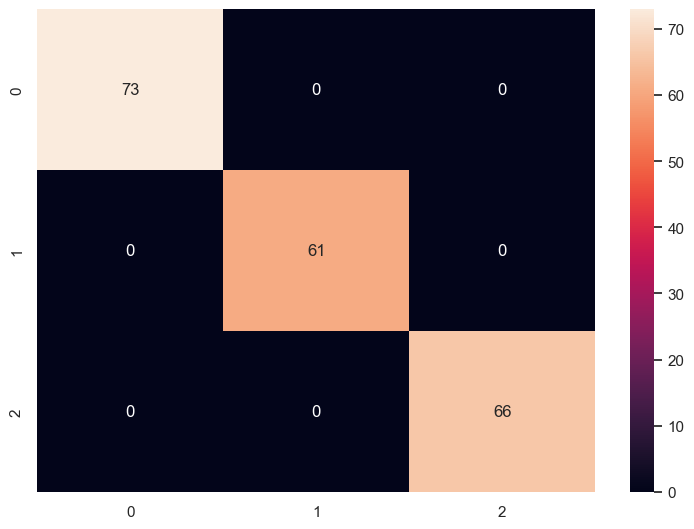

In [48]:
#Creating the Confusion matrix  
from sklearn.metrics import confusion_matrix  
cm= confusion_matrix(Y_test, prediction1) 
sns.heatmap(cm, annot=True)

## Summarizing all Predictions

In [49]:
print('The accuracy of the Logistic Regression is: ', metrics.accuracy_score(X_test_prediction, Y_test))
print('The accuracy of the SVM is: ', metrics.accuracy_score(prediction_svm, Y_test))
print('The accuracy of Decision Tree is: ', metrics.accuracy_score(prediction_dis, Y_test))
print('The accuracy of KNN is: ', metrics.accuracy_score(prediction1, Y_test))

The accuracy of the Logistic Regression is:  0.955
The accuracy of the SVM is:  1.0
The accuracy of Decision Tree is:  1.0
The accuracy of KNN is:  1.0


In [50]:
import pickle
filename = "final_model.sav"
pickle.dump(classifier , open(filename,'wb'))